# Nifty50 Experiment Runner

Workmanlike Colab runner for long multimodal experiments. It installs the project, mounts Google Drive when available, builds a fresh real-world multimodal artifact, checks modality independence before training, runs all ablation variants with purged walk-forward CV, runs the corrected backtest on the best variant, and writes a consolidated `summary.md` under the output directory.

Expected runtime depends on universe size, history length, GPU availability, and FinBERT download/cache state. The default 6-stock smoke configuration is intended to finish within a Colab session; 50 stocks over 5 years is a long unattended run. A separate demo notebook will explain the results later; this notebook only produces experiment artifacts.

In [2]:
%%capture setup_log
# Setup - environment. Re-run is safe; pip output is captured unless this cell fails.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/Randhir123/nifty50-multimodal-transformer.git"
REPO_DIR = Path("/content/nifty50-multimodal-transformer")

if not Path("pyproject.toml").exists():
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)
else:
    os.chdir(Path.cwd())

subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-e", "."], check=True)
print(f"Repository ready at {Path.cwd()}")

In [3]:
# Setup - Google Drive mount. Outside Colab this falls back to local output paths.
from pathlib import Path

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    IN_COLAB = True
    print("Google Drive mounted at /content/drive")
except Exception as exc:
    print(f"Not running in Colab or Drive mount skipped: {exc}")
    print("Outputs will use the configured path if available, otherwise a local fallback.")

Mounted at /content/drive
Google Drive mounted at /content/drive


In [4]:
# =====================================================================
# === EXPERIMENT CONFIG - EDIT THIS CELL ONLY ==========================
# =====================================================================

TICKERS = "RELIANCE.NS,TCS.NS,INFY.NS,HDFCBANK.NS,ICICIBANK.NS,SBIN.NS"
# Comma-separated NSE tickers. Default is the 6-stock smoke set.
# For full Nifty 50 expansion, paste the full list here.

PEER_TICKERS = "ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BAJAJFINSV.NS,BEL.NS,BHARTIARTL.NS,CIPLA.NS,COALINDIA.NS,DRREDDY.NS,EICHERMOT.NS,ETERNAL.NS,GRASIM.NS,HCLTECH.NS,HDFCLIFE.NS,HINDALCO.NS,HINDUNILVR.NS,INDIGO.NS,ITC.NS,JIOFIN.NS,JSWSTEEL.NS,KOTAKBANK.NS,LT.NS,M&M.NS,MARUTI.NS,MAXHEALTH.NS,NESTLEIND.NS,NTPC.NS,ONGC.NS,POWERGRID.NS,SBILIFE.NS,SHRIRAMFIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS"
# Extra OHLCV-only tickers used only for KG peer/sector features.
# Leave blank to compute KG from the training universe only.

PERIOD = "1y"
# yfinance period string. Use "1y", "2y", "5y", "10y", or "max".
# Longer periods need more compute and exercise more market regimes.

WINDOW_SIZE = 20
HORIZON_DAYS = 3
# OHLCV window length and forward-return horizon. These match the leakage-test assumptions.

EPOCHS = 20
BATCH_SIZE = 16
# Training schedule per ablation variant per fold.

CV_SPLITS = 3
EMBARGO_DAYS = 3
# Walk-forward purged CV. Embargo is in calendar days.

OUTPUT_ROOT = "/content/drive/MyDrive/nifty50_experiments"
# Where artifacts are written. A timestamped subdirectory is created.
# Outside Colab, this falls back to ./outputs/nifty50_experiments if Drive is unavailable.

RAW_DATA_DIR = ""
# Optional: paste a previous run's raw folder to reuse downloaded OHLCV CSVs.
# Example: "/content/drive/MyDrive/nifty50_experiments/20260510_123456/raw"
# Leave blank to use this run's OUTPUT_DIR/raw and download missing files only.

FORCE_REFRESH = False
# Keep False to use cached ticker CSVs when present. Set True only when you intentionally want fresh yfinance downloads.

DEVICE = "cuda"
# Set to "cpu" if no GPU is available. The next cell will fall back automatically if needed.

In [5]:
# Resolved paths and fixed experiment constants.
import json
import os
import random
import time
from datetime import date, datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import torch

RANDOM_SEED = 42  # Fixed by design. Multi-seed evaluation needs a different runner structure.
MODEL_DIM = 16    # Session-5 trainer-collapse-safe compact model config.
NUM_HEADS = 4
NUM_LAYERS = 1
FF_DIM = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.1
POOLING = "mean"
BENCHMARK = "^NSEI"
ABLATION_VARIANTS = ["tabular_only", "tabular_kg", "tabular_image", "tabular_text", "tabular_image_text_kg"]

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
else:
    if DEVICE == "cuda":
        print("CUDA requested but unavailable; falling back to CPU.")
    DEVICE = "cpu"

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
if OUTPUT_ROOT.startswith("/content/drive") and not Path("/content/drive").exists():
    OUTPUT_ROOT = "outputs/nifty50_experiments"
OUTPUT_DIR = Path(OUTPUT_ROOT) / RUN_ID
RAW_DIR = Path(RAW_DATA_DIR).expanduser() if RAW_DATA_DIR.strip() else OUTPUT_DIR / "raw"
ABLATION_DIR = OUTPUT_DIR / "ablations"
BACKTEST_DIR = OUTPUT_DIR / "backtest"
for path in [OUTPUT_DIR, RAW_DIR, ABLATION_DIR, BACKTEST_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TICKER_LIST = [ticker.strip() for ticker in TICKERS.split(",") if ticker.strip()]
PEER_TICKER_LIST = [ticker.strip() for ticker in PEER_TICKERS.split(",") if ticker.strip()]
PEER_UNIVERSE_TICKERS = list(dict.fromkeys([*TICKER_LIST, *PEER_TICKER_LIST]))
END_DATE = date.today().isoformat()

def resolve_start_date(period: str, end: str) -> str:
    if period == "max":
        return "1990-01-01"
    end_date = pd.Timestamp(end).date()
    if period.endswith("y"):
        return (end_date - timedelta(days=int(period[:-1]) * 365)).isoformat()
    if period.endswith("mo"):
        return (end_date - timedelta(days=int(period[:-2]) * 31)).isoformat()
    raise ValueError("PERIOD must look like '1y', '5y', '10y', '9mo', or 'max'.")

START_DATE = resolve_start_date(PERIOD, END_DATE)
EXPERIMENT_START_TIME = time.time()
STEP_RESULTS = {"config": {}}
STEP_ERRORS = {}

CONFIG = {
    "tickers": TICKER_LIST,
    "peer_tickers": PEER_TICKER_LIST,
    "peer_universe_tickers": PEER_UNIVERSE_TICKERS,
    "period": PERIOD,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "window_size": WINDOW_SIZE,
    "horizon_days": HORIZON_DAYS,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "cv_splits": CV_SPLITS,
    "embargo_days": EMBARGO_DAYS,
    "output_dir": str(OUTPUT_DIR),
    "raw_dir": str(RAW_DIR),
    "force_refresh": FORCE_REFRESH,
    "device": DEVICE,
    "seed": RANDOM_SEED,
    "model_dim": MODEL_DIM,
    "variants": ABLATION_VARIANTS,
}
STEP_RESULTS["config"] = CONFIG
print(json.dumps(CONFIG, indent=2))

CUDA requested but unavailable; falling back to CPU.
{
  "tickers": [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "SBIN.NS"
  ],
  "peer_tickers": [
    "ADANIENT.NS",
    "ADANIPORTS.NS",
    "APOLLOHOSP.NS",
    "ASIANPAINT.NS",
    "AXISBANK.NS",
    "BAJAJ-AUTO.NS",
    "BAJFINANCE.NS",
    "BAJAJFINSV.NS",
    "BEL.NS",
    "BHARTIARTL.NS",
    "CIPLA.NS",
    "COALINDIA.NS",
    "DRREDDY.NS",
    "EICHERMOT.NS",
    "ETERNAL.NS",
    "GRASIM.NS",
    "HCLTECH.NS",
    "HDFCLIFE.NS",
    "HINDALCO.NS",
    "HINDUNILVR.NS",
    "INDIGO.NS",
    "ITC.NS",
    "JIOFIN.NS",
    "JSWSTEEL.NS",
    "KOTAKBANK.NS",
    "LT.NS",
    "M&M.NS",
    "MARUTI.NS",
    "MAXHEALTH.NS",
    "NESTLEIND.NS",
    "NTPC.NS",
    "ONGC.NS",
    "POWERGRID.NS",
    "SBILIFE.NS",
    "SHRIRAMFIN.NS",
    "SUNPHARMA.NS",
    "TATACONSUM.NS",
    "TATASTEEL.NS",
    "TECHM.NS",
    "TITAN.NS",
    "TRENT.NS",
    "ULTRACEMCO.NS",
    "WIPRO.NS"
  ],
  "peer_u

In [6]:
# Build multimodal samples with retry around yfinance and FinBERT download/encoding.
import dataclasses
import gc
import traceback
from argparse import Namespace
from pathlib import Path

from scripts.run_real_world_demo import (
    DEFAULT_SECTORS,
    FEATURE_COLUMNS,
    _attach_finbert_text_tokens,
    _build_event_records,
    _build_kg_returns,
    _build_tabular_rows,
    _build_text_records,
)
from src.data.download_yfinance import (
    deterministic_csv_path_for_ticker,
    download_benchmark_data,
    download_single_ticker_ohlcv,
    save_ticker_csv,
)
from src.data.multimodal_samples import (
    attach_gaf_mtf_image_tokens,
    attach_kg_v2_tokens,
    build_tabular_multimodal_samples,
    save_multimodal_samples,
)


def retry_call(label, fn, attempts=3, base_sleep=5):
    last_exc = None
    for attempt in range(1, attempts + 1):
        try:
            return fn()
        except Exception as exc:
            last_exc = exc
            print(f"{label} failed on attempt {attempt}/{attempts}: {exc}")
            if attempt < attempts:
                time.sleep(base_sleep * (2 ** (attempt - 1)))
    raise last_exc


def load_or_download_with_retries(tickers, benchmark, start, end, raw_dir, force_refresh=False):
    provenance = {}
    stock_data = {}
    today = date.today()
    failures = {}

    for ticker in tickers:
        csv_path = deterministic_csv_path_for_ticker(ticker, raw_dir)
        if csv_path.exists() and not force_refresh:
            stock_data[ticker] = pd.read_csv(csv_path, parse_dates=["date"])
            provenance[ticker] = f"cache:{csv_path}"
            continue
        try:
            df = retry_call(
                f"download {ticker}",
                lambda ticker=ticker: download_single_ticker_ohlcv(ticker, start=start, end=end),
            )
            save_path = save_ticker_csv(ticker, df, output_dir=raw_dir)
            stock_data[ticker] = df
            provenance[ticker] = f"download:{save_path}"
        except Exception as exc:
            failures[ticker] = repr(exc)
            print(f"Skipping {ticker} after retries: {exc}")

    if len(stock_data) < max(1, len(tickers) // 2):
        raise RuntimeError(f"Only {len(stock_data)}/{len(tickers)} tickers succeeded; failures={failures}")

    benchmark_path = deterministic_csv_path_for_ticker(benchmark, raw_dir)
    if benchmark_path.exists() and not force_refresh:
        benchmark_df = pd.read_csv(benchmark_path, parse_dates=["date"])
        provenance[benchmark] = f"cache:{benchmark_path}"
    else:
        benchmark_df = retry_call(
            f"download {benchmark}",
            lambda: download_benchmark_data(benchmark, start=start, end=end),
        )
        save_path = save_ticker_csv(benchmark, benchmark_df, output_dir=raw_dir)
        provenance[benchmark] = f"download:{save_path}"

    return stock_data, benchmark_df, provenance, failures

try:
    all_ohlcv, benchmark_df, provenance, download_failures = load_or_download_with_retries(
        PEER_UNIVERSE_TICKERS, BENCHMARK, START_DATE, END_DATE, RAW_DIR, force_refresh=FORCE_REFRESH
    )
    stock_data = {ticker: all_ohlcv[ticker] for ticker in TICKER_LIST if ticker in all_ohlcv}
    peer_data = {ticker: all_ohlcv[ticker] for ticker in PEER_UNIVERSE_TICKERS if ticker in all_ohlcv}
    missing_training = sorted(set(TICKER_LIST) - set(stock_data))
    if missing_training:
        raise RuntimeError(f"Missing OHLCV for training tickers: {missing_training}")

    tabular_df = _build_tabular_rows(
        stock_data=stock_data,
        benchmark_df=benchmark_df,
        horizon_days=HORIZON_DAYS,
    )
    TABULAR_CSV = OUTPUT_DIR / "tabular_samples.csv"
    tabular_df.to_csv(TABULAR_CSV, index=False)

    text_records = _build_text_records(tabular_df)
    TEXT_RECORDS_CSV = OUTPUT_DIR / "text_records.csv"
    text_records.to_csv(TEXT_RECORDS_CSV, index=False)

    sectors = {ticker: DEFAULT_SECTORS[ticker] for ticker in peer_data.keys()}
    stock_sectors = pd.DataFrame([{"stock_id": ticker, "sector_id": sector} for ticker, sector in sectors.items()])
    stock_sectors.to_csv(OUTPUT_DIR / "stock_sectors.csv", index=False)

    kg_returns = _build_kg_returns(tabular_df)
    kg_returns.to_csv(OUTPUT_DIR / "kg_returns.csv", index=False)
    event_records = _build_event_records(tabular_df)
    event_records.to_csv(OUTPUT_DIR / "event_records.csv", index=False)

    arrays = build_tabular_multimodal_samples(tabular_df, feature_cols=FEATURE_COLUMNS, window_size=WINDOW_SIZE)
    arrays = retry_call("FinBERT text encoding", lambda: _attach_finbert_text_tokens(arrays, text_records, device=DEVICE), attempts=3, base_sleep=10)
    arrays = attach_kg_v2_tokens(
        arrays,
        universe_ohlcv=stock_data,
        peer_ohlcv=peer_data,
        benchmark_ohlcv=benchmark_df,
        sector_mapping=sectors,
    )
    arrays = attach_gaf_mtf_image_tokens(arrays, raw_dir=RAW_DIR, image_size=32, output_dim=MODEL_DIM, device=DEVICE)

    DATASET_PATH = save_multimodal_samples(arrays, OUTPUT_DIR / "real_world_multimodal_samples.npz")
    STEP_RESULTS["data_build"] = {
        "dataset_path": str(DATASET_PATH),
        "tabular_csv": str(TABULAR_CSV),
        "text_records_csv": str(TEXT_RECORDS_CSV),
        "download_failures": download_failures,
        "peer_tickers": PEER_TICKER_LIST,
        "peer_universe_tickers": PEER_UNIVERSE_TICKERS,
        "peer_tickers_loaded": sorted(peer_data),
        "provenance": provenance,
    }
    del all_ohlcv, stock_data, peer_data, benchmark_df, text_records, kg_returns, event_records
    gc.collect()
except Exception as exc:
    STEP_ERRORS["data_build"] = traceback.format_exc()
    print(STEP_ERRORS["data_build"])

/content/nifty50-multimodal-transformer/src/data/features.py:95: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  index_return_1d = df["index_close"].pct_change(1)
/content/nifty50-multimodal-transformer/src/data/features.py:95: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  index_return_1d = df["index_close"].pct_change(1)
/content/nifty50-multimodal-transformer/src/data/features.py:95: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=N

Fetching real news from yfinance...
Encoding text records using FinBERT...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
# Artifact summary. Stop here manually if the sample count or label balance looks wrong.
try:
    data = np.load(DATASET_PATH, allow_pickle=False)
    y = data["y"]
    dates = pd.to_datetime(data["end_dates"])
    artifact_summary = {
        "samples": int(y.shape[0]),
        "date_min": str(dates.min().date()),
        "date_max": str(dates.max().date()),
        "positive_label_rate": float(np.mean(y)),
        "tabular_shape": list(data["tabular_tokens"].shape),
        "image_shape": list(data["image_tokens"].shape) if "image_tokens" in data.files else None,
        "text_shape": list(data["text_tokens"].shape) if "text_tokens" in data.files else None,
        "kg_shape": list(data["kg_tokens"].shape) if "kg_tokens" in data.files else None,
    }
    STEP_RESULTS["artifact_summary"] = artifact_summary
    print(json.dumps(artifact_summary, indent=2))
except Exception:
    STEP_ERRORS["artifact_summary"] = traceback.format_exc()
    print(STEP_ERRORS["artifact_summary"])

{
  "samples": 1260,
  "date_min": "2025-07-03",
  "date_max": "2026-05-08",
  "positive_label_rate": 0.4507936507936508,
  "tabular_shape": [
    1260,
    20,
    11
  ],
  "image_shape": [
    1260,
    16
  ],
  "text_shape": [
    1260,
    768
  ],
  "kg_shape": [
    1260,
    37
  ]
}


In [8]:
# Modality independence check before training.
try:
    from scripts.check_modality_independence import _mean_abs_corr, _prepare

    raw = {}
    data = np.load(DATASET_PATH, allow_pickle=False)
    for key, label in [
        ("tabular_tokens", "tabular"),
        ("text_tokens", "text"),
        ("image_tokens", "image"),
        ("kg_tokens", "kg"),
    ]:
        if key in data.files:
            raw[label] = _prepare(data[key], max_dim=50)

    names = list(raw.keys())
    table = {
        i: {j: (1.0 if i == j else _mean_abs_corr(raw[i], raw[j])) for j in names}
        for i in names
    }
    independence_df = pd.DataFrame(table, index=names)
    INDEPENDENCE_CSV = OUTPUT_DIR / "modality_independence.csv"
    independence_df.to_csv(INDEPENDENCE_CSV)
    STEP_RESULTS["modality_independence"] = independence_df.round(4).to_dict()
    display(independence_df.style.format("{:.4f}"))
except Exception:
    STEP_ERRORS["modality_independence"] = traceback.format_exc()
    print(STEP_ERRORS["modality_independence"])

,tabular,text,image,kg
tabular,1.0000,0.1434,0.1310,0.1662
text,0.1434,1.0000,0.0858,0.1730
image,0.1310,0.0858,1.0000,0.0575
kg,0.1662,0.1730,0.0575,1.0000


In [9]:
# Run ablations with fold-level checkpoint resume.
try:
    import csv
    from scripts.run_ablation_study import (
        DEFAULT_VARIANTS,
        aggregate_fold_metrics,
        available_dataset_keys,
        load_checkpoint_metrics,
        load_checkpoint_predictions,
        select_variants,
        summarize_predictions,
        write_diagnostics,
        write_fold_results,
        write_results,
    )
    from src.training.cv import PurgedWalkForwardSplit
    from src.training.train_fusion import FusionArrays, load_fusion_arrays, slice_fusion_arrays, train_on_arrays

    def make_variant_arrays(full_arrays, variant):
        return FusionArrays(
            tabular_tokens=full_arrays.tabular_tokens,
            y=full_arrays.y,
            end_dates=full_arrays.end_dates,
            image_tokens=full_arrays.image_tokens if variant.use_image else None,
            text_tokens=full_arrays.text_tokens if variant.use_text else None,
            kg_tokens=full_arrays.kg_tokens if variant.use_kg else None,
            stock_ids=full_arrays.stock_ids,
        )

    train_args = Namespace(
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        model_dim=MODEL_DIM,
        num_heads=NUM_HEADS,
        num_layers=NUM_LAYERS,
        ff_dim=FF_DIM,
        val_fraction=0.25,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        dropout=DROPOUT,
        pooling=POOLING,
        max_tokens=4096,
    )

    dataset_keys = available_dataset_keys(DATASET_PATH)
    variants = select_variants(dataset_keys, variants=DEFAULT_VARIANTS, strict=True)
    full_arrays = load_fusion_arrays(
        DATASET_PATH,
        use_image="image_tokens" in dataset_keys,
        use_text="text_tokens" in dataset_keys,
        use_kg="kg_tokens" in dataset_keys,
    )
    splitter = PurgedWalkForwardSplit(n_splits=CV_SPLITS, horizon_days=HORIZON_DAYS, embargo_days=EMBARGO_DAYS)
    checkpoint_dir = ABLATION_DIR / "checkpoints"
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    results = []
    all_fold_rows = []
    for variant in variants:
        print(f"Running CV ablation variant: {variant.name}")
        variant_arrays = make_variant_arrays(full_arrays, variant)
        fold_metrics_list = []
        for cv_split in splitter.split(full_arrays.end_dates):
            fold_k = cv_split.fold
            checkpoint_path = checkpoint_dir / f"{variant.name}_fold{fold_k}.pt"
            if checkpoint_path.exists():
                print(f"  fold {fold_k}: using existing checkpoint {checkpoint_path}")
                fold_val_metrics = load_checkpoint_metrics(checkpoint_path)
            else:
                print(f"  fold {fold_k}: train={len(cv_split.train_idx)} val={len(cv_split.val_idx)}")
                train_arrays = slice_fusion_arrays(variant_arrays, cv_split.train_idx)
                val_arrays = slice_fusion_arrays(variant_arrays, cv_split.val_idx)
                fold_val_metrics = train_on_arrays(train_arrays, val_arrays, args=train_args, checkpoint_path=checkpoint_path)

            fold_metrics_list.append(fold_val_metrics)
            y_true, y_prob, end_dates, stock_ids = load_checkpoint_predictions(checkpoint_path)
            diagnostics = summarize_predictions(y_true, y_prob)
            all_fold_rows.append({
                "variant": variant.name,
                "fold": fold_k,
                "modalities": "+".join(variant.modalities),
                "checkpoint_path": str(checkpoint_path),
                **fold_val_metrics,
                **diagnostics,
            })
            write_fold_results(all_fold_rows, ABLATION_DIR)

        aggregated = aggregate_fold_metrics(fold_metrics_list)
        results.append({
            "variant": variant.name,
            "modalities": "+".join(variant.modalities),
            "n_folds": len(fold_metrics_list),
            "checkpoint_path": str(checkpoint_dir / f"{variant.name}_fold*.pt"),
            "prediction_scores_path": "",
            "command": f"notebook_cv:{len(fold_metrics_list)} folds",
            "accuracy": aggregated.get("accuracy_mean", ""),
            "precision": aggregated.get("precision_mean", ""),
            "recall": aggregated.get("recall_mean", ""),
            "f1": aggregated.get("f1_mean", ""),
            "roc_auc": aggregated.get("roc_auc_mean", ""),
            **aggregated,
        })
        write_results(results, ABLATION_DIR)
        write_diagnostics(results, ABLATION_DIR)

    ABLATION_RESULTS_CSV, ABLATION_RESULTS_JSON = write_results(results, ABLATION_DIR)
    write_diagnostics(results, ABLATION_DIR)
    ablation_df = pd.DataFrame(results).sort_values("roc_auc_mean", ascending=False)
    STEP_RESULTS["ablations"] = {
        "results_csv": str(ABLATION_RESULTS_CSV),
        "best_variant": str(ablation_df.iloc[0]["variant"]),
        "best_roc_auc_mean": float(ablation_df.iloc[0]["roc_auc_mean"]),
    }
    display(ablation_df[["variant", "roc_auc_mean", "roc_auc_std", "accuracy_mean", "f1_mean"]])
except Exception:
    STEP_ERRORS["ablations"] = traceback.format_exc()
    print(STEP_ERRORS["ablations"])

Running CV ablation variant: tabular_only
  fold 0: train=300 val=315


/content/nifty50-multimodal-transformer/src/models/fusion.py:87: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch 001 | train_loss=0.8161 val_loss=0.8332 | train_f1=0.3861 val_f1=0.6875
Epoch 002 | train_loss=0.8119 val_loss=0.8367 | train_f1=0.5449 val_f1=0.6875
Epoch 003 | train_loss=0.8104 val_loss=0.8442 | train_f1=0.4051 val_f1=0.0000
Epoch 004 | train_loss=0.8105 val_loss=0.8358 | train_f1=0.4413 val_f1=0.6875
Epoch 005 | train_loss=0.8244 val_loss=0.8433 | train_f1=0.5167 val_f1=0.0000
Epoch 006 | train_loss=0.8137 val_loss=0.8438 | train_f1=0.3721 val_f1=0.0000
Epoch 007 | train_loss=0.8098 val_loss=0.8452 | train_f1=0.3426 val_f1=0.0000
Epoch 008 | train_loss=0.8145 val_loss=0.8344 | train_f1=0.5165 val_f1=0.6875
Epoch 009 | train_loss=0.8162 val_loss=0.8338 | train_f1=0.5015 val_f1=0.6875
Epoch 010 | train_loss=0.8098 val_loss=0.8411 | train_f1=0.5000 val_f1=0.0000
Epoch 011 | train_loss=0.8085 val_loss=0.8438 | train_f1=0.4506 val_f1=0.0000
Epoch 012 | train_loss=0.8042 val_loss=0.8477 | train_f1=0.3005 val_f1=0.0000
Epoch 013 | train_loss=0.8106 val_loss=0.8335 | train_f1=0.4421 

/content/nifty50-multimodal-transformer/src/models/fusion.py:87: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch 001 | train_loss=0.7528 val_loss=0.7442 | train_f1=0.4760 val_f1=0.6304
Epoch 002 | train_loss=0.7491 val_loss=0.7449 | train_f1=0.5054 val_f1=0.0000
Epoch 003 | train_loss=0.7449 val_loss=0.7424 | train_f1=0.3191 val_f1=0.6304
Epoch 004 | train_loss=0.7470 val_loss=0.7424 | train_f1=0.5695 val_f1=0.0000
Epoch 005 | train_loss=0.7489 val_loss=0.7419 | train_f1=0.4650 val_f1=0.0000
Epoch 006 | train_loss=0.7466 val_loss=0.7423 | train_f1=0.4860 val_f1=0.0000
Epoch 007 | train_loss=0.7464 val_loss=0.7443 | train_f1=0.2711 val_f1=0.6304
Epoch 008 | train_loss=0.7447 val_loss=0.7420 | train_f1=0.5710 val_f1=0.0000
Epoch 009 | train_loss=0.7443 val_loss=0.7426 | train_f1=0.4272 val_f1=0.0000
Epoch 010 | train_loss=0.7472 val_loss=0.7418 | train_f1=0.4970 val_f1=0.0000
Epoch 011 | train_loss=0.7434 val_loss=0.7430 | train_f1=0.4100 val_f1=0.6304
Epoch 012 | train_loss=0.7440 val_loss=0.7418 | train_f1=0.5506 val_f1=0.0000
Epoch 013 | train_loss=0.7488 val_loss=0.7416 | train_f1=0.5350 

...

/content/nifty50-multimodal-transformer/src/models/fusion.py:87: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch 001 | train_loss=0.7581 val_loss=0.7422 | train_f1=0.5078 val_f1=0.4771
Epoch 002 | train_loss=0.7509 val_loss=0.7425 | train_f1=0.3555 val_f1=0.0000
Epoch 003 | train_loss=0.7428 val_loss=0.7416 | train_f1=0.5367 val_f1=0.6269
Epoch 004 | train_loss=0.7461 val_loss=0.7405 | train_f1=0.4575 val_f1=0.6337
Epoch 005 | train_loss=0.7451 val_loss=0.7402 | train_f1=0.4258 val_f1=0.6304
Epoch 006 | train_loss=0.7458 val_loss=0.7375 | train_f1=0.5230 val_f1=0.2712
Epoch 007 | train_loss=0.7391 val_loss=0.7347 | train_f1=0.5497 val_f1=0.6368
Epoch 008 | train_loss=0.7425 val_loss=0.7291 | train_f1=0.5234 val_f1=0.4141
Epoch 009 | train_loss=0.7364 val_loss=0.7297 | train_f1=0.5333 val_f1=0.3646
Epoch 010 | train_loss=0.7375 val_loss=0.7181 | train_f1=0.5409 val_f1=0.4957
Epoch 011 | train_loss=0.7300 val_loss=0.7156 | train_f1=0.5288 val_f1=0.4891
Epoch 012 | train_loss=0.7287 val_loss=0.7171 | train_f1=0.5770 val_f1=0.5171
Epoch 013 | train_loss=0.7294 val_loss=0.7303 | train_f1=0.5436 

/content/nifty50-multimodal-transformer/src/models/fusion.py:87: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch 001 | train_loss=0.7388 val_loss=0.7452 | train_f1=0.4452 val_f1=0.5714
Epoch 002 | train_loss=0.7395 val_loss=0.7326 | train_f1=0.4995 val_f1=0.5527
Epoch 003 | train_loss=0.7343 val_loss=0.7247 | train_f1=0.5437 val_f1=0.2123
Epoch 004 | train_loss=0.7293 val_loss=0.7357 | train_f1=0.4582 val_f1=0.2123
Epoch 005 | train_loss=0.7362 val_loss=0.7331 | train_f1=0.4884 val_f1=0.2123
Epoch 006 | train_loss=0.7269 val_loss=0.7387 | train_f1=0.4562 val_f1=0.2123
Epoch 007 | train_loss=0.7262 val_loss=0.7329 | train_f1=0.4706 val_f1=0.2304
Epoch 008 | train_loss=0.7297 val_loss=0.7827 | train_f1=0.5190 val_f1=0.4615
Epoch 009 | train_loss=0.7231 val_loss=0.7470 | train_f1=0.5317 val_f1=0.2123
Epoch 010 | train_loss=0.7229 val_loss=0.7419 | train_f1=0.5050 val_f1=0.2123
Epoch 011 | train_loss=0.7186 val_loss=0.7845 | train_f1=0.5126 val_f1=0.4625
Epoch 012 | train_loss=0.7226 val_loss=0.7534 | train_f1=0.4878 val_f1=0.2123
Epoch 013 | train_loss=0.7181 val_loss=0.7524 | train_f1=0.5208 

,variant,roc_auc_mean,roc_auc_std,accuracy_mean,f1_mean
4,tabular_image_text_kg,0.518813,0.071178,0.568254,0.462958
3,tabular_text,0.517880,0.085284,0.579894,0.401809
1,tabular_kg,0.505684,0.058359,0.547090,0.369005
2,tabular_image,0.483275,0.075431,0.554497,0.229167
0,tabular_only,0.478317,0.076245,0.577778,0.399153


{
  "best_variant": "tabular_image_text_kg",
  "predictions_csv": "/content/drive/MyDrive/nifty50_experiments/20260510_132752/ablations/prediction_scores_tabular_image_text_kg_cv.csv",
  "metrics": {
    "total_return_model": 0.05060065047032691,
    "total_return_benchmark": -0.04556210891621737,
    "trading_days": 157,
    "rebalance_dates": 155,
    "avg_position_count": 2.961783439490446,
    "sharpe_ratio": 0.9092578255325078,
    "max_drawdown_model": -0.20231309214488835,
    "note_sharpe": "Risk-free rate = 0, 252 trading days/year assumed",
    "return_source": "real_forward_returns"
  },
  "plot": "/content/drive/MyDrive/nifty50_experiments/20260510_132752/backtest/backtest_curve.png"
}


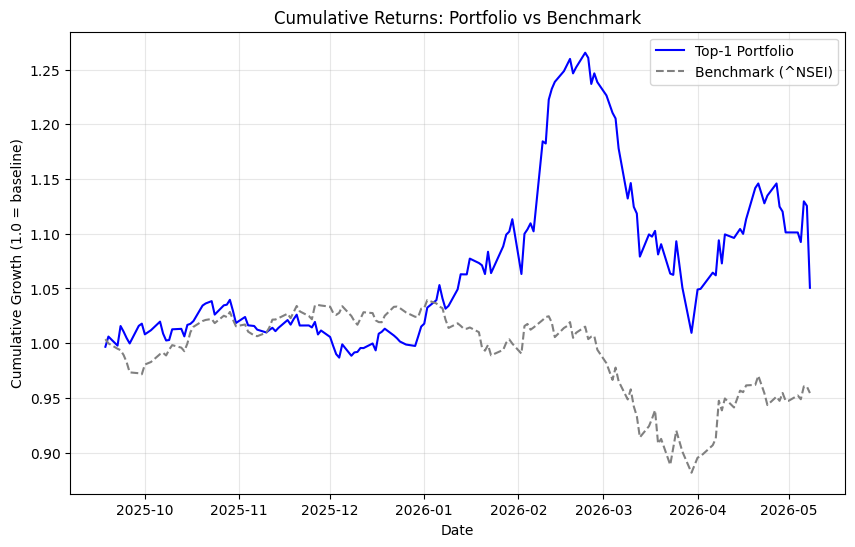

In [10]:
# Aggregate CV prediction scores for the best variant and run the corrected backtest.
try:
    from scripts.run_ablation_study import load_checkpoint_predictions

    ablation_df = pd.read_csv(ABLATION_DIR / "ablation_results.csv")
    best_row = ablation_df.sort_values("roc_auc_mean", ascending=False).iloc[0]
    BEST_VARIANT = str(best_row["variant"])
    BEST_PREDICTIONS_CSV = ABLATION_DIR / f"prediction_scores_{BEST_VARIANT}_cv.csv"

    rows = []
    for fold_k in range(CV_SPLITS):
        ckpt = ABLATION_DIR / "checkpoints" / f"{BEST_VARIANT}_fold{fold_k}.pt"
        y_true, y_prob, end_dates, stock_ids = load_checkpoint_predictions(ckpt)
        y_pred = (y_prob >= 0.5).astype(int)
        for i, (label, prob, pred) in enumerate(zip(y_true, y_prob, y_pred)):
            rows.append({
                "row_id": f"fold{fold_k}_{i}",
                "fold": fold_k,
                "end_date": "" if end_dates is None else str(end_dates[i]),
                "stock_id": "" if stock_ids is None else str(stock_ids[i]),
                "y_true": int(label),
                "y_prob": float(prob),
                "y_pred": int(pred),
            })
    pd.DataFrame(rows).to_csv(BEST_PREDICTIONS_CSV, index=False)

    command = [
        sys.executable,
        "scripts/run_backtest.py",
        "--predictions", str(BEST_PREDICTIONS_CSV),
        "--tabular-samples", str(TABULAR_CSV),
        "--raw-dir", str(RAW_DIR),
        "--output-dir", str(BACKTEST_DIR),
        "--horizon-days", str(HORIZON_DAYS),
        "--top-k", "1",
    ]
    subprocess.run(command, check=True)

    with open(BACKTEST_DIR / "backtest_metrics.json", "r", encoding="utf-8") as handle:
        backtest_metrics = json.load(handle)
    STEP_RESULTS["backtest"] = {
        "best_variant": BEST_VARIANT,
        "predictions_csv": str(BEST_PREDICTIONS_CSV),
        "metrics": backtest_metrics,
        "plot": str(BACKTEST_DIR / "backtest_curve.png"),
    }
    print(json.dumps(STEP_RESULTS["backtest"], indent=2))
    try:
        from IPython.display import Image, display
        display(Image(filename=str(BACKTEST_DIR / "backtest_curve.png")))
    except Exception:
        pass
except Exception:
    STEP_ERRORS["backtest"] = traceback.format_exc()
    print(STEP_ERRORS["backtest"])

In [11]:
# Write summary.md. This cell is intentionally defensive and should run even after partial failures.
def markdown_table(df, include_index=False):
    if df is None or df.empty:
        return "_No rows._"
    out = df.copy()
    if include_index:
        out = out.reset_index().rename(columns={"index": "modality"})
    headers = [str(c) for c in out.columns]
    rows = []
    for _, row in out.iterrows():
        rows.append([str(row[c]) for c in out.columns])
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines.extend("| " + " | ".join(row) + " |" for row in rows)
    return "\n".join(lines)

try:
    total_runtime_minutes = (time.time() - EXPERIMENT_START_TIME) / 60
except Exception:
    total_runtime_minutes = None

summary_lines = [
    "# Nifty50 Experiment Summary",
    "",
    f"- Run ID: `{globals().get('RUN_ID', 'unknown')}`",
    f"- Output directory: `{globals().get('OUTPUT_DIR', 'unknown')}`",
    f"- Total runtime minutes: `{total_runtime_minutes:.2f}`" if total_runtime_minutes is not None else "- Total runtime minutes: `unknown`",
    "",
    "## Config",
    "",
    "```json",
    json.dumps(globals().get("CONFIG", {}), indent=2, default=str),
    "```",
    "",
]

summary_lines += ["## Artifact", ""]
summary_lines += ["```json", json.dumps(STEP_RESULTS.get("artifact_summary", {}), indent=2, default=str), "```", ""]

summary_lines += ["## Modality Independence", ""]
try:
    summary_lines.append(markdown_table(pd.read_csv(OUTPUT_DIR / "modality_independence.csv", index_col=0), include_index=True))
except Exception as exc:
    summary_lines.append(f"_Not available: {exc}_")
summary_lines.append("")

summary_lines += ["## Ablation Results", ""]
try:
    cols = ["variant", "roc_auc_mean", "roc_auc_std", "accuracy_mean", "f1_mean"]
    df = pd.read_csv(ABLATION_DIR / "ablation_results.csv")
    summary_lines.append(markdown_table(df.loc[:, [c for c in cols if c in df.columns]]))
except Exception as exc:
    summary_lines.append(f"_Not available: {exc}_")
summary_lines.append("")

summary_lines += ["## Backtest", ""]
try:
    with open(BACKTEST_DIR / "backtest_metrics.json", "r", encoding="utf-8") as handle:
        metrics = json.load(handle)
    summary_lines += ["```json", json.dumps(metrics, indent=2), "```"]
except Exception as exc:
    summary_lines.append(f"_Not available: {exc}_")
summary_lines.append("")

summary_lines += ["## Errors", ""]
if STEP_ERRORS:
    for name, err in STEP_ERRORS.items():
        summary_lines += [f"### {name}", "", "```text", err[-4000:], "```", ""]
else:
    summary_lines.append("No recorded step errors.")
    summary_lines.append("")

SUMMARY_MD = OUTPUT_DIR / "summary.md"
SUMMARY_MD.write_text("\n".join(summary_lines), encoding="utf-8")
print(f"Summary written to {SUMMARY_MD}")

Summary written to /content/drive/MyDrive/nifty50_experiments/20260510_132752/summary.md


In [12]:
# Done.
print("Done.")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Summary: {SUMMARY_MD if 'SUMMARY_MD' in globals() else OUTPUT_DIR / 'summary.md'}")
if STEP_ERRORS:
    print("Completed with recorded errors; see summary.md for details.")

Done.
Output directory: /content/drive/MyDrive/nifty50_experiments/20260510_132752
Summary: /content/drive/MyDrive/nifty50_experiments/20260510_132752/summary.md
